# Internship Project: Student Performance Predictor
**Submitted by:** Aryan Singh Tariani
**Problem Statement 2:** Predicting a student's performance index using multiple input features.



In [2]:

import pandas as pd
import numpy as np





In [4]:

df = pd.read_csv("Student_Performance.csv")

In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 6


In [8]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\aryan\AppData\Local\Temp\ipykernel_9472\374293907.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [10]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\aryan\AppData\Local\Temp\ipykernel_9472\3842376714.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 127


In [13]:
df = df.drop_duplicates()

In [14]:
print(df.duplicated().sum())

0


In [15]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [16]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [17]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes":1,
    "No":0
})

In [18]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [20]:
import matplotlib.pyplot as plt

In [22]:
import seaborn as sns

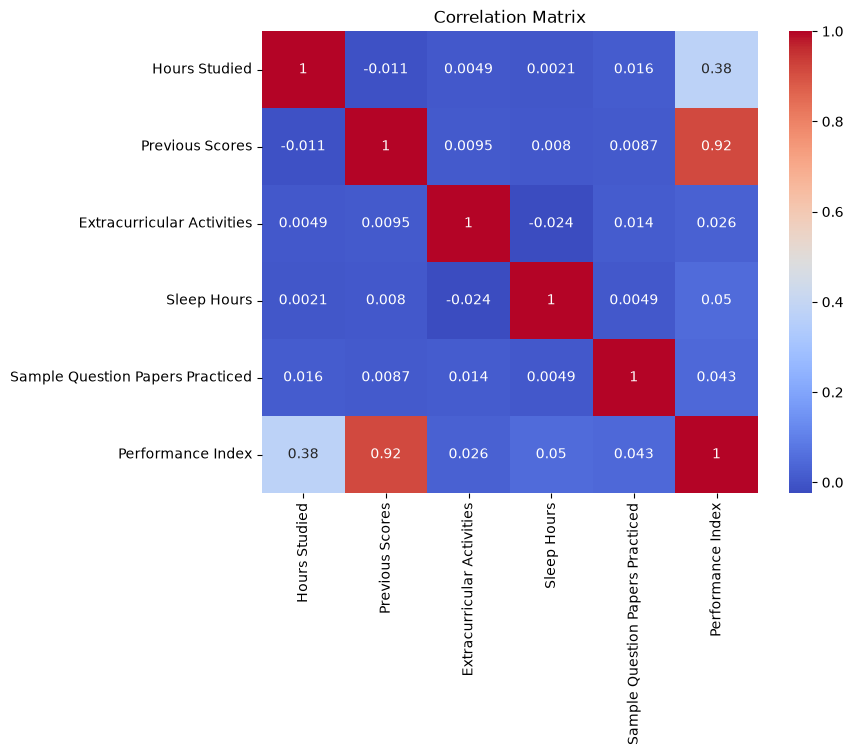

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [24]:
X = df.drop("Performance Index",axis=1)

y = df["Performance Index"]

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test)

In [30]:
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred
})

comparison.head(15)

,Actual,Predicted
0,47.0,46.480013
1,76.0,80.285379
2,62.0,61.065188
3,23.0,22.706315
4,76.0,74.836868
5,83.0,84.194968
6,60.0,61.993141
7,51.0,50.337443
8,38.0,38.898681
9,58.0,55.753202


In [31]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("Mean Absolute Error :",mae)

print("Mean Squared Error :",mse)

print("Root Mean Squared Error :",rmse)

print("R2 Score :",r2)

Mean Absolute Error : 1.6469703984255568
Mean Squared Error : 4.305900938538476
Root Mean Squared Error : 2.075066490148804
R2 Score : 0.9884301209927054


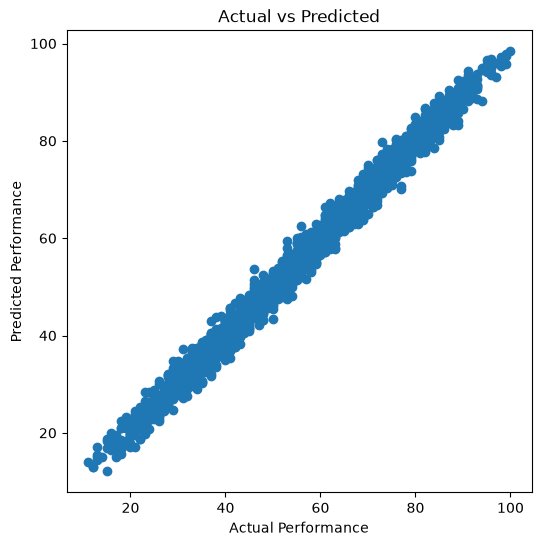

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Performance")

plt.ylabel("Predicted Performance")

plt.title("Actual vs Predicted")

plt.show()

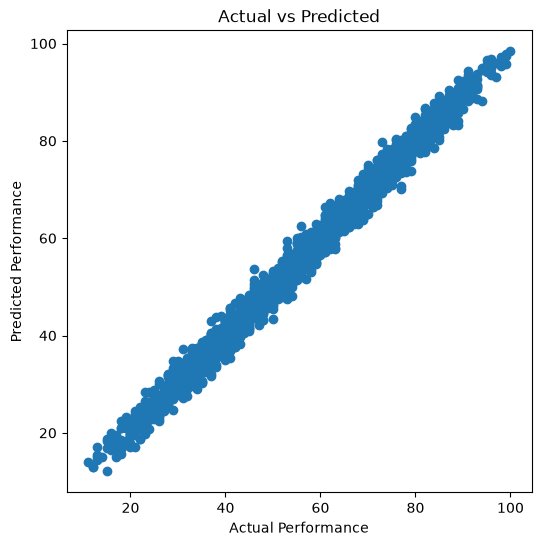

In [33]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Performance")

plt.ylabel("Predicted Performance")

plt.title("Actual vs Predicted")

plt.show()

In [36]:
print("Model Training Completed Successfully b y Aryan Singh Tariani!")

print("R2 Score :",round(r2,2))

print("This model can predict the student Performance Index using multiple input features.")

Model Training Completed Successfully b y Aryan Singh Tariani!
R2 Score : 0.99
This model can predict the student Performance Index using multiple input features.
